In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib

In [2]:
products_path = "../data/raw/amazon_products.csv"
categories_path = "../data/raw/amazon_categories.csv"

In [3]:
products_sample = pd.read_csv(products_path,nrows=5)

categories_sample = pd.read_csv(categories_path, nrows=5)

In [4]:
products_sample.head()

,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth
0,B014TMV5YE,"Sion Softside Expandable Roller Luggage, Black...",https://m.media-amazon.com/images/I/815dLQKYIY...,https://www.amazon.com/dp/B014TMV5YE,4.5,0,139.99,0.00,104,False,2000
1,B07GDLCQXV,Luggage Sets Expandable PC+ABS Durable Suitcas...,https://m.media-amazon.com/images/I/81bQlm7vf6...,https://www.amazon.com/dp/B07GDLCQXV,4.5,0,169.99,209.99,104,False,1000
2,B07XSCCZYG,Platinum Elite Softside Expandable Checked Lug...,https://m.media-amazon.com/images/I/71EA35zvJB...,https://www.amazon.com/dp/B07XSCCZYG,4.6,0,365.49,429.99,104,False,300
3,B08MVFKGJM,Freeform Hardside Expandable with Double Spinn...,https://m.media-amazon.com/images/I/91k6NYLQyI...,https://www.amazon.com/dp/B08MVFKGJM,4.6,0,291.59,354.37,104,False,400
4,B01DJLKZBA,Winfield 2 Hardside Expandable Luggage with Sp...,https://m.media-amazon.com/images/I/61NJoaZcP9...,https://www.amazon.com/dp/B01DJLKZBA,4.5,0,174.99,309.99,104,False,400


In [5]:
categories_sample.head()

,id,category_name
0,1,Beading & Jewelry Making
1,2,Fabric Decorating
2,3,Knitting & Crochet Supplies
3,4,Printmaking Supplies
4,5,Scrapbooking & Stamping Supplies


In [6]:
products_sample.columns.tolist()

['asin',
 'title',
 'imgUrl',
 'productURL',
 'stars',
 'reviews',
 'price',
 'listPrice',
 'category_id',
 'isBestSeller',
 'boughtInLastMonth']

In [7]:
categories_sample.columns.tolist()

['id', 'category_name']

In [8]:
products_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   asin               5 non-null      str    
 1   title              5 non-null      str    
 2   imgUrl             5 non-null      str    
 3   productURL         5 non-null      str    
 4   stars              5 non-null      float64
 5   reviews            5 non-null      int64  
 6   price              5 non-null      float64
 7   listPrice          5 non-null      float64
 8   category_id        5 non-null      int64  
 9   isBestSeller       5 non-null      bool   
 10  boughtInLastMonth  5 non-null      int64  
dtypes: bool(1), float64(3), int64(3), str(4)
memory usage: 1.5 KB


In [9]:
categories_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             5 non-null      int64
 1   category_name  5 non-null      str  
dtypes: int64(1), str(1)
memory usage: 332.0 bytes


In [10]:
categories = pd.read_csv(categories_path)

In [11]:
categories.shape

(248, 2)

In [12]:
print("Number of categories:", categories['id'].nunique())

Number of categories: 248


In [13]:
categories.head()

,id,category_name
0,1,Beading & Jewelry Making
1,2,Fabric Decorating
2,3,Knitting & Crochet Supplies
3,4,Printmaking Supplies
4,5,Scrapbooking & Stamping Supplies


In [14]:
print(products_sample[['asin','category_id']])

         asin  category_id
0  B014TMV5YE          104
1  B07GDLCQXV          104
2  B07XSCCZYG          104
3  B08MVFKGJM          104
4  B01DJLKZBA          104


In [15]:
print(categories_sample[['id','category_name']].head())

   id                     category_name
0   1          Beading & Jewelry Making
1   2                 Fabric Decorating
2   3       Knitting & Crochet Supplies
3   4              Printmaking Supplies
4   5  Scrapbooking & Stamping Supplies


In [16]:
print(products_sample['category_id'].dtype)
print(categories_sample['id'].dtype)

int64
int64


In [17]:
common_ids = set(products_sample['category_id']) & set(categories['id'])

print("Common IDs:", common_ids)
print("Number of common IDs:", len(common_ids))

Common IDs: {104}
Number of common IDs: 1


In [18]:
categories_sample['id'].nunique()

5

In [19]:
merged_sample = products_sample.merge(
    categories,
    left_on='category_id',
    right_on='id',
    how='left'
)

print(merged_sample[['asin', 'category_id', 'category_name']])

         asin  category_id category_name
0  B014TMV5YE          104     Suitcases
1  B07GDLCQXV          104     Suitcases
2  B07XSCCZYG          104     Suitcases
3  B08MVFKGJM          104     Suitcases
4  B01DJLKZBA          104     Suitcases


In [20]:
df = pd.read_csv(
    products_path,
    nrows=100000
)

In [21]:
df.shape

(100000, 11)

In [22]:
df.head()

,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth
0,B014TMV5YE,"Sion Softside Expandable Roller Luggage, Black...",https://m.media-amazon.com/images/I/815dLQKYIY...,https://www.amazon.com/dp/B014TMV5YE,4.5,0,139.99,0.00,104,False,2000
1,B07GDLCQXV,Luggage Sets Expandable PC+ABS Durable Suitcas...,https://m.media-amazon.com/images/I/81bQlm7vf6...,https://www.amazon.com/dp/B07GDLCQXV,4.5,0,169.99,209.99,104,False,1000
2,B07XSCCZYG,Platinum Elite Softside Expandable Checked Lug...,https://m.media-amazon.com/images/I/71EA35zvJB...,https://www.amazon.com/dp/B07XSCCZYG,4.6,0,365.49,429.99,104,False,300
3,B08MVFKGJM,Freeform Hardside Expandable with Double Spinn...,https://m.media-amazon.com/images/I/91k6NYLQyI...,https://www.amazon.com/dp/B08MVFKGJM,4.6,0,291.59,354.37,104,False,400
4,B01DJLKZBA,Winfield 2 Hardside Expandable Luggage with Sp...,https://m.media-amazon.com/images/I/61NJoaZcP9...,https://www.amazon.com/dp/B01DJLKZBA,4.5,0,174.99,309.99,104,False,400


In [23]:
df.tail()

,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth
99995,B09XFK69N3,Run DMC Fleece Pullover Sweatshirt Little Kid ...,https://m.media-amazon.com/images/I/61M5WV47Bd...,https://www.amazon.com/dp/B09XFK69N3,4.6,46,19.19,0.0,84,False,0
99996,B0C1FB8393,Boys' USA Catboats Long-Sleeve Harbor Performa...,https://m.media-amazon.com/images/I/619-PvshJj...,https://www.amazon.com/dp/B0C1FB8393,5.0,1,32.88,42.0,84,False,0
99997,B09GC97655,Monster Jam Boys' Dragon Zombie Grave Digger M...,https://m.media-amazon.com/images/I/81AA3uv1ni...,https://www.amazon.com/dp/B09GC97655,4.4,13,16.95,0.0,84,False,0
99998,B01GS70WYC,Toddler Boy Pull on Jeans Baby Denim Pants B103,https://m.media-amazon.com/images/I/81FkP32jWh...,https://www.amazon.com/dp/B01GS70WYC,4.6,258,18.99,0.0,84,False,0
99999,B075XHHWXT,Boys Girls Ultralight Puffer Down Jacket Stand...,https://m.media-amazon.com/images/I/71F9FjK0fb...,https://www.amazon.com/dp/B075XHHWXT,0.0,0,24.99,0.0,84,False,0


In [24]:
df.shape

(100000, 11)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   asin               100000 non-null  str    
 1   title              100000 non-null  str    
 2   imgUrl             100000 non-null  str    
 3   productURL         100000 non-null  str    
 4   stars              100000 non-null  float64
 5   reviews            100000 non-null  int64  
 6   price              100000 non-null  float64
 7   listPrice          100000 non-null  float64
 8   category_id        100000 non-null  int64  
 9   isBestSeller       100000 non-null  bool   
 10  boughtInLastMonth  100000 non-null  int64  
dtypes: bool(1), float64(3), int64(3), str(4)
memory usage: 26.4 MB


In [26]:
df.describe(include="all")

,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth
count,100000,100000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000,100000.000000
unique,100000,96439,96308,100000,NaN,NaN,NaN,NaN,NaN,2,NaN
top,B014TMV5YE,Men's Ultraboost 23 Running Shoe,https://m.media-amazon.com/images/I/71u96R-Cb1...,https://www.amazon.com/dp/B014TMV5YE,NaN,NaN,NaN,NaN,NaN,False,NaN
freq,1,81,38,1,NaN,NaN,NaN,NaN,NaN,99626,NaN
mean,NaN,NaN,NaN,NaN,4.078889,470.320500,48.397080,18.057276,118.819380,NaN,33.313000
std,NaN,NaN,NaN,NaN,1.191573,2878.566625,73.609606,48.913972,51.827728,NaN,193.861084
min,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,69.000000,NaN,0.000000
25%,NaN,NaN,NaN,NaN,4.100000,0.000000,16.990000,0.000000,91.000000,NaN,0.000000
50%,NaN,NaN,NaN,NaN,4.400000,0.000000,26.990000,0.000000,110.000000,NaN,0.000000
75%,NaN,NaN,NaN,NaN,4.600000,128.000000,50.380000,14.990000,114.000000,NaN,0.000000


In [27]:
df.isna().sum()

asin                 0
title                0
imgUrl               0
productURL           0
stars                0
reviews              0
price                0
listPrice            0
category_id          0
isBestSeller         0
boughtInLastMonth    0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['stars', 'reviews', 'price', 'listPrice', 'category_id', 'boughtInLastMonth']

Categorical columns:
['asin', 'title', 'imgUrl', 'productURL']


C:\Users\Acer\AppData\Local\Temp\ipykernel_28240\1582412579.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


In [30]:
df[[
    "price",
    "listPrice",
    "stars",
    "reviews"
]].describe()

,price,listPrice,stars,reviews
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,48.397080,18.057276,4.078889,470.320500
std,73.609606,48.913972,1.191573,2878.566625
min,0.000000,0.000000,0.000000,0.000000
25%,16.990000,0.000000,4.100000,0.000000
50%,26.990000,0.000000,4.400000,0.000000
75%,50.380000,14.990000,4.600000,128.000000
max,4999.000000,999.990000,5.000000,292474.000000


In [31]:
df["price"].isna().sum()

np.int64(0)

In [32]:
(df["price"]==0).sum()

np.int64(3298)

In [33]:
df["stars"].value_counts().sort_index()

stars
0.0     6979
1.0      264
1.2        1
1.3        1
1.4        1
1.5       13
1.6        1
1.7        4
1.8        5
1.9       11
2.0      126
2.1       14
2.2       18
2.3       19
2.4       35
2.5       71
2.6       49
2.7       61
2.8       83
2.9       98
3.0      452
3.1      207
3.2      244
3.3      429
3.4      538
3.5      818
3.6      898
3.7     1257
3.8     1737
3.9     2362
4.0     3882
4.1     4761
4.2     6636
4.3     9121
4.4    11252
4.5    13557
4.6    12816
4.7     9776
4.8     4549
4.9     1151
5.0     5703
Name: count, dtype: int64

In [34]:
df["is_free"] = (df["price"]==0).astype(int)

In [35]:
df["is_free"].sum()

np.int64(3298)

### # Log-transform price to reduce right skew


In [36]:
df["log_price"] = np.log1p(df['price'])

### Handle listPrice
# 0 generally indicates that no list price is available

In [37]:
df['has_list_price'] = (df['listPrice'] > 0).astype(int)

### # Convert 0 to missing value

In [38]:
df['listPrice'] = df['listPrice'].replace(0, np.nan)

### Handle stars and reviews
# 0 reviews means the product has no review activity

In [39]:
df['is_reviewed'] = (df['reviews']>0).astype(int)

### If there are no reviews, a 0-star value represents unrated/missing data

In [40]:
df.loc[df['reviews']== 0, 'stars'] = np.nan

In [41]:
df[['price','listPrice','stars','reviews','is_free','log_price','has_list_price','is_reviewed']].head()

,price,listPrice,stars,reviews,is_free,log_price,has_list_price,is_reviewed
0,139.99,NaN,NaN,0,0,4.948689,0,0
1,169.99,209.99,NaN,0,0,5.141605,1,0
2,365.49,429.99,NaN,0,0,5.903971,1,0
3,291.59,354.37,NaN,0,0,5.678772,1,0
4,174.99,309.99,NaN,0,0,5.170427,1,0


In [42]:
df[['price', 'listPrice', 'stars', 'reviews']].isna().sum()

price            0
listPrice    72697
stars        50872
reviews          0
dtype: int64

In [43]:
df[['price', 'listPrice', 'stars', 'reviews']].describe()

,price,listPrice,stars,reviews
count,100000.000000,27303.000000,49128.000000,100000.000000
mean,48.397080,66.136599,4.392756,470.320500
std,73.609606,74.721937,0.451905,2878.566625
min,0.000000,3.990000,1.000000,0.000000
25%,16.990000,23.000000,4.200000,0.000000
50%,26.990000,39.990000,4.500000,0.000000
75%,50.380000,79.995000,4.700000,128.000000
max,4999.000000,999.990000,5.000000,292474.000000


In [44]:
df['listPrice'].describe()

count    27303.000000
mean        66.136599
std         74.721937
min          3.990000
25%         23.000000
50%         39.990000
75%         79.995000
max        999.990000
Name: listPrice, dtype: float64

In [45]:
df['stars'].describe()

count    49128.000000
mean         4.392756
std          0.451905
min          1.000000
25%          4.200000
50%          4.500000
75%          4.700000
max          5.000000
Name: stars, dtype: float64

In [46]:
df['has_list_price'].value_counts()

has_list_price
0    72697
1    27303
Name: count, dtype: int64

In [47]:
df['is_reviewed'].value_counts()

is_reviewed
0    50872
1    49128
Name: count, dtype: int64

In [48]:
df['listPrice'] = df['listPrice'].fillna(0)

In [49]:
df['listPrice'].isna().sum()

np.int64(0)

In [50]:
df['log_listPrice'] = np.log1p(df['listPrice'])

In [51]:
df[['listPrice', 'has_list_price']].head(10)

,listPrice,has_list_price
0,0.00,0
1,209.99,1
2,429.99,1
3,354.37,1
4,309.99,1
5,0.00,0
6,0.00,0
7,0.00,0
8,137.04,1
9,0.00,0


In [52]:
df['stars'] = df['stars'].fillna(df['stars'].median())

In [53]:
df['stars'].isna().sum()

np.int64(0)

### Select the numeric, engineered features for clustering

In [54]:
features = ['log_price','log_listPrice','stars','reviews','is_free','has_list_price','is_reviewed']
X = df[features]

In [55]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [56]:
X_scaled

array([[ 1.50062418, -0.59326951,  0.16400701, ..., -0.18467478,
        -0.61283977, -0.98270946],
       [ 1.6876794 ,  2.45229727,  0.16400701, ..., -0.18467478,
         1.63174789, -0.98270946],
       [ 2.42688449,  2.85877084,  0.16400701, ..., -0.18467478,
         1.63174789, -0.98270946],
       ...,
       [-0.49785744, -0.59326951, -0.14727852, ..., -0.18467478,
        -0.61283977,  1.01759476],
       [-0.39348562, -0.59326951,  0.47529253, ..., -0.18467478,
        -0.61283977,  1.01759476],
       [-0.13898019, -0.59326951,  0.16400701, ..., -0.18467478,
        -0.61283977, -0.98270946]], shape=(100000, 7))

### Finding the optimal k - Elbow Method

In [57]:
inertia = []

k_range = range(1, 11)

for k in k_range:

    kmean = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmean.fit(X_scaled)

    inertia.append(kmean.inertia_)



### Plot Elbow curve

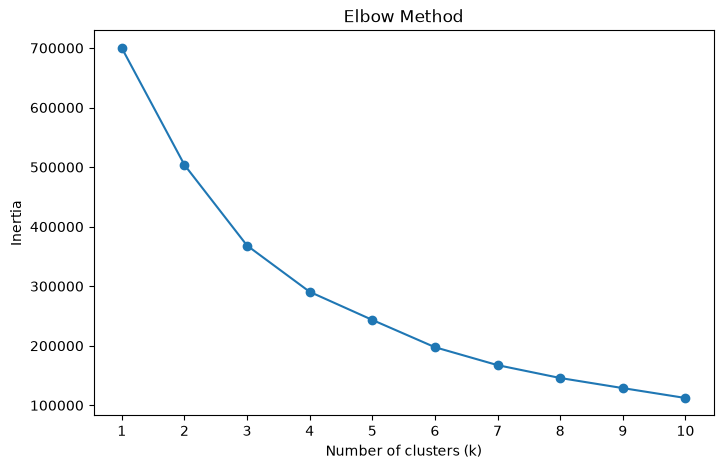

In [58]:
plt.figure(figsize=(8, 5))
plt.plot(
    k_range,
    inertia,
    marker='o'
)
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.show()

### Silhouette score

In [60]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

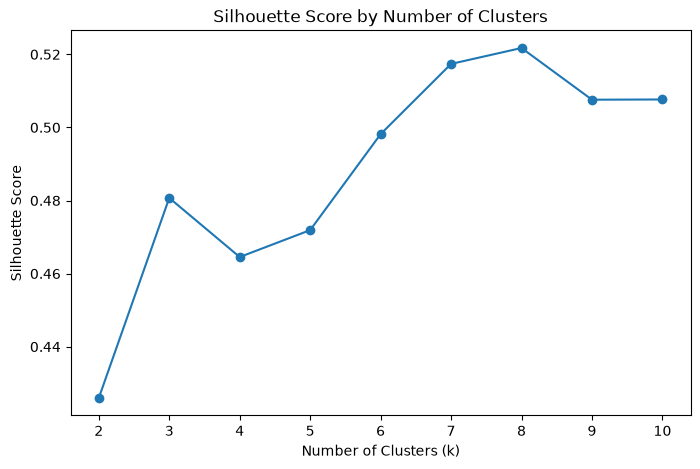

In [61]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.show()

In [62]:
optimal_k = 8

kmeans = KMeans(
    n_clusters= optimal_k,
    random_state= 42,
    n_init= 10
)

clusters = kmeans.fit_predict(X_scaled)

In [63]:
df['Cluster'] = clusters

df.head()

,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth,is_free,log_price,has_list_price,is_reviewed,log_listPrice,Cluster
0,B014TMV5YE,"Sion Softside Expandable Roller Luggage, Black...",https://m.media-amazon.com/images/I/815dLQKYIY...,https://www.amazon.com/dp/B014TMV5YE,4.5,0,139.99,0.00,104,False,2000,0,4.948689,0,0,0.000000,4
1,B07GDLCQXV,Luggage Sets Expandable PC+ABS Durable Suitcas...,https://m.media-amazon.com/images/I/81bQlm7vf6...,https://www.amazon.com/dp/B07GDLCQXV,4.5,0,169.99,209.99,104,False,1000,0,5.141605,1,0,5.351811,5
2,B07XSCCZYG,Platinum Elite Softside Expandable Checked Lug...,https://m.media-amazon.com/images/I/71EA35zvJB...,https://www.amazon.com/dp/B07XSCCZYG,4.5,0,365.49,429.99,104,False,300,0,5.903971,1,0,6.066085,5
3,B08MVFKGJM,Freeform Hardside Expandable with Double Spinn...,https://m.media-amazon.com/images/I/91k6NYLQyI...,https://www.amazon.com/dp/B08MVFKGJM,4.5,0,291.59,354.37,104,False,400,0,5.678772,1,0,5.873160,5
4,B01DJLKZBA,Winfield 2 Hardside Expandable Luggage with Sp...,https://m.media-amazon.com/images/I/61NJoaZcP9...,https://www.amazon.com/dp/B01DJLKZBA,4.5,0,174.99,309.99,104,False,400,0,5.170427,1,0,5.739761,5


In [65]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

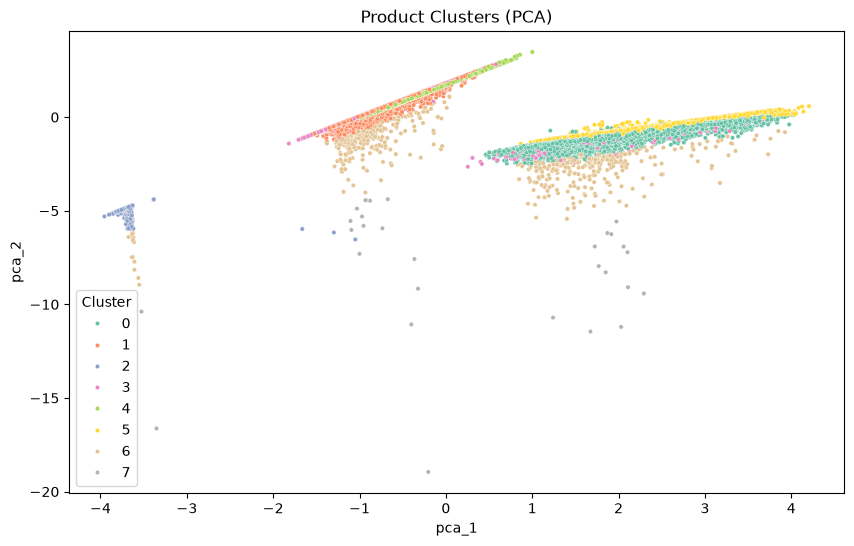

In [69]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pca_1', y='pca_2', hue='Cluster', palette='Set2', s=10)
plt.title('Product Clusters (PCA)')
plt.show()

In [71]:
cluster_summary = df.groupby('Cluster')[['price', 'stars', 'reviews', 'is_free']].mean()
print(cluster_summary)

             price     stars        reviews   is_free
Cluster                                              
0        37.107426  4.455060     975.267162  0.000000
1        33.418303  4.541757     591.266214  0.000000
2         0.000000  4.447806     364.766301  1.000000
3        42.199148  3.562625     212.498713  0.000000
4        66.532850  4.499932       0.084032  0.000000
5        59.332087  4.499822       0.315737  0.000000
6        41.290502  4.502913   20466.208738  0.022654
7        24.166667  4.493333  107950.866667  0.066667
